In [ ]:
import torch
import hdf5storage
import numpy as np 
from scipy import ndimage
from matplotlib import pyplot as plt

from utils_dpir import utils_image as util
from utils.utilities import compute_PSNR
from forward_operators.forward_operators_deblur import * 
from deal import DEAL

In [2]:
device = 'cuda:0'

path_ckp = "trained_models/deal_gray.pth"
ckp = torch.load(path_ckp, map_location={'cuda:0':device,'cuda:1':device,'cuda:2':device,'cuda:3':device})

model = DEAL(color=False)
model.to(device)
model.load_state_dict(ckp['state_dict'])
model.eval()


kernels = hdf5storage.loadmat('/home/pourya/ICML_2025/Levin09.mat')['kernels']


/tmp/ipykernel_1969489/4070055326.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckp = torch.load(path_ckp, map_location={'cuda:0':device,'cuda:1':device,'cuda:2':devic

------------------------------------------ 255 0.5 ---------------------------------------------
-------------- size of kernel: (17, 17) --------------


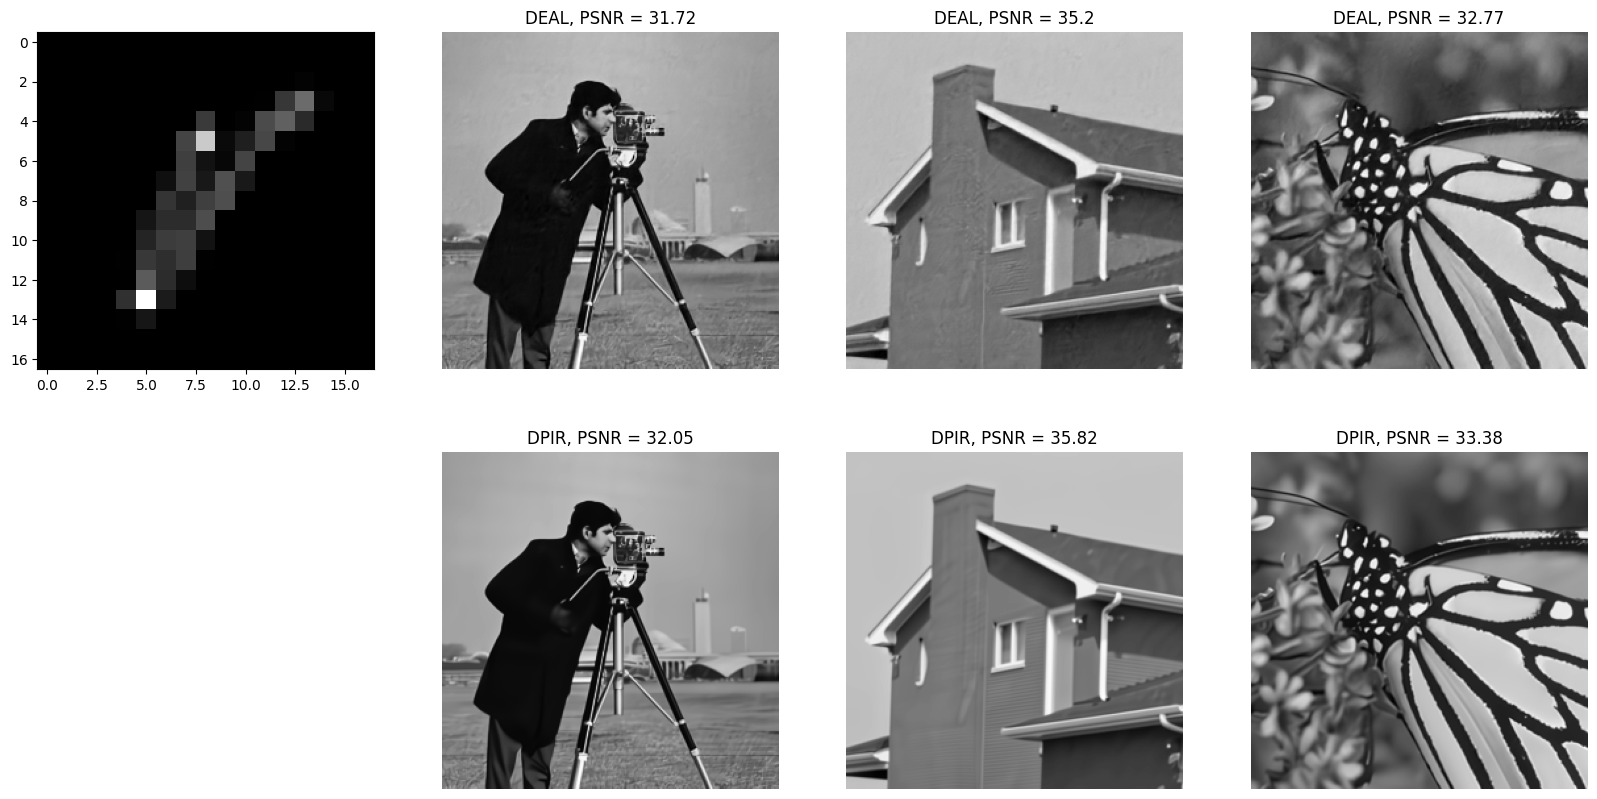

-------------- size of kernel: (27, 27) --------------


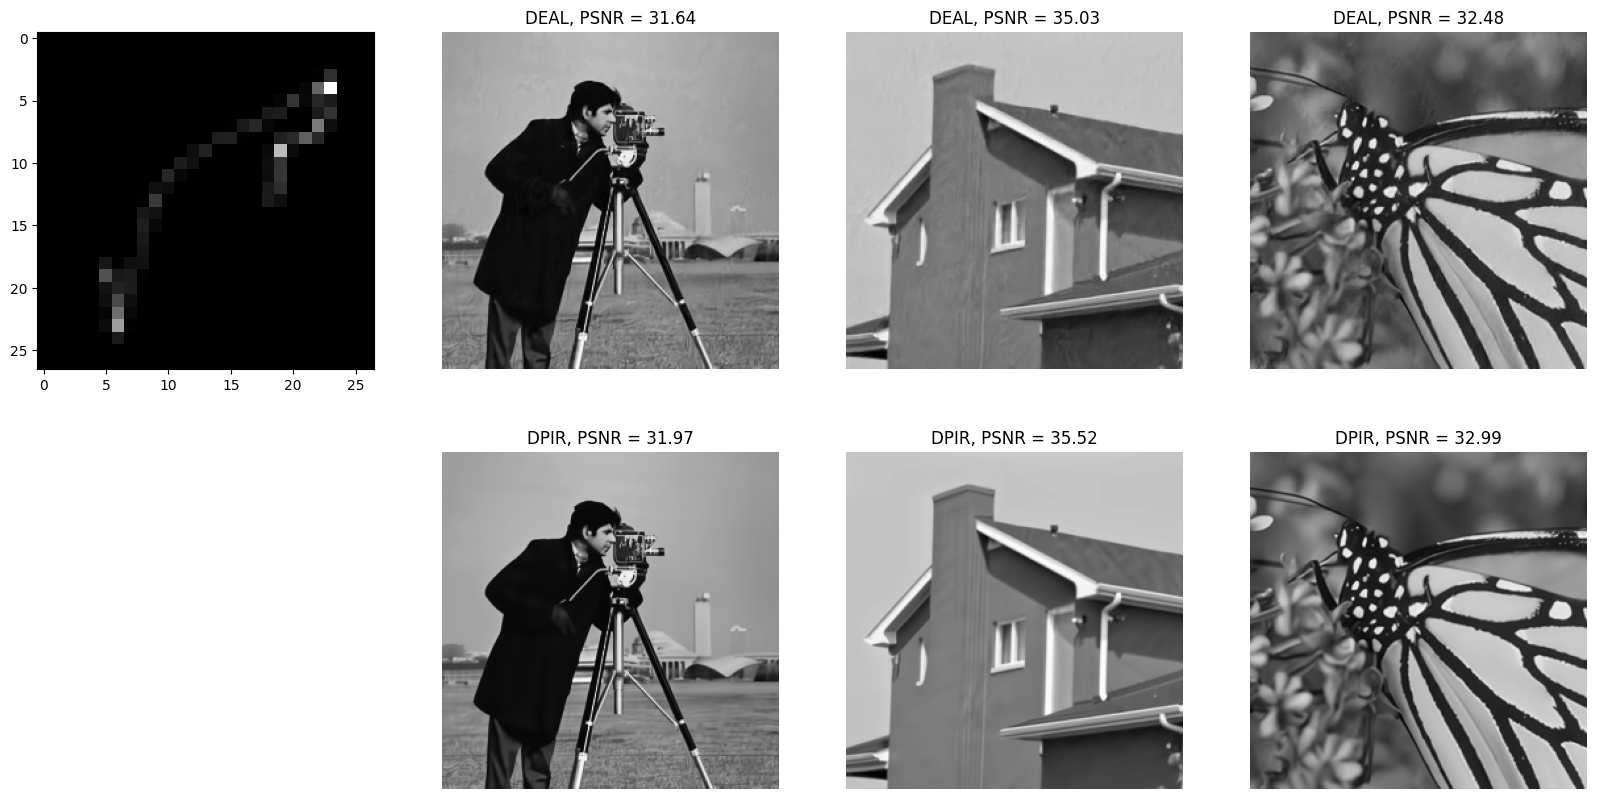

------------------------------------------ 765 2.5 ---------------------------------------------
-------------- size of kernel: (17, 17) --------------


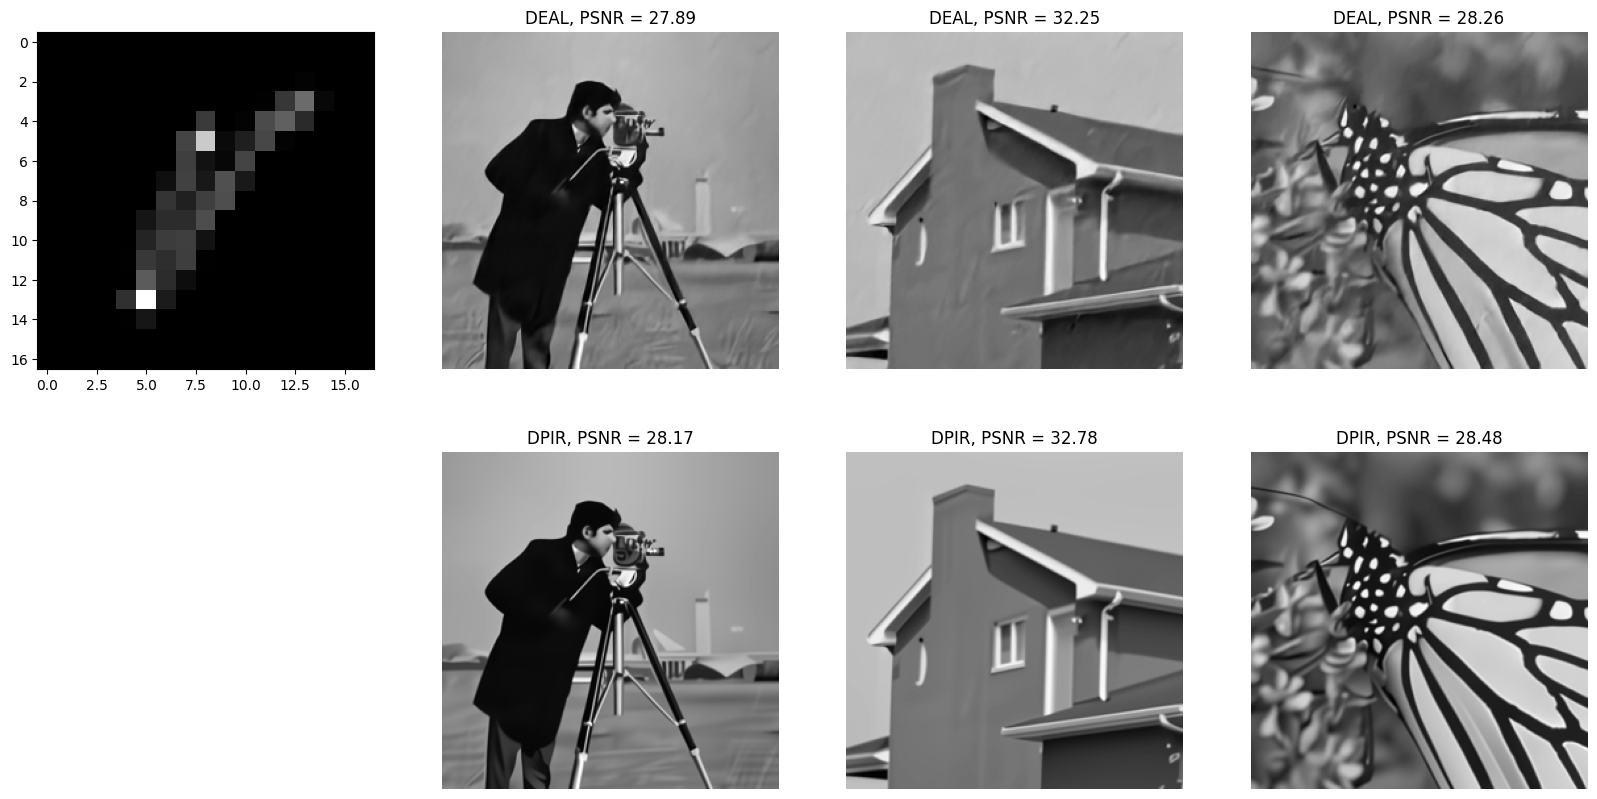

-------------- size of kernel: (27, 27) --------------


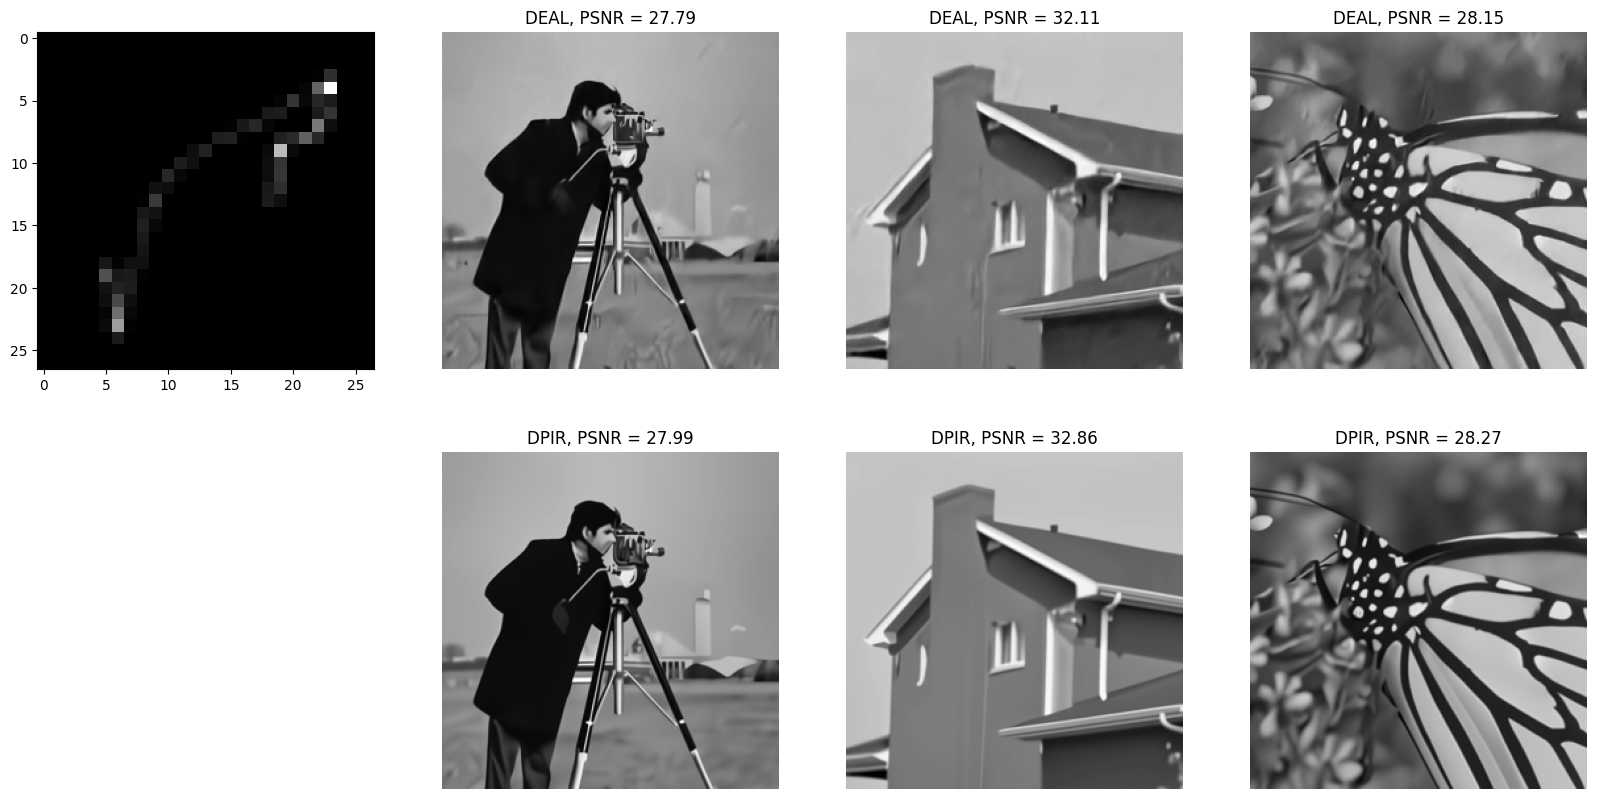

In [3]:
eps_in = 1e-8
eps_out = 1e-5
sigma = 15
lmbdas = [0.5, 2.5]

reses = []
for n, noise_level_img in enumerate(['255', '765']): #to trad 2.55 and 7.65 data, I get the measurements generated from dpir code to be fair
    lmbda = lmbdas[n]
    print('------------------------------------------', noise_level_img, lmbda, '---------------------------------------------')
    for kenerl_idx in [1, 3]:
        
        plt.figure(figsize=(20, 10))

        k = kernels[0, kenerl_idx].astype(np.float64)
        print('-------------- size of kernel:', k.shape, '--------------')
        k_tensor = util.single2tensor4(np.expand_dims(k, 2)).to(device)
        k_tensor[0, 0] = k_tensor[0, 0].fliplr().flipud()

        plt.subplot(2, 4, 1)
        plt.imshow(k, cmap='gray')

        def H_blur(x):
            F =  torch.nn.functional
            x =  F.conv2d(F.pad(x, pad=(k_tensor.size(2)//2,)*4, mode='circular'), k_tensor)
            return x

        def Ht_blur(x):
            mirrored_filter = k_tensor.clone()
            mirrored_filter[0, 0] = k_tensor[0, 0].fliplr().flipud()
            out = torch.nn.functional.conv_transpose2d(x, k_tensor)
            out = periodic_pad_transpose(out, pad_size=(k_tensor.size(2)//2,)*4)
            return out
        
        for i, img_name in enumerate(['01', '02', '05']):

            img_H = util.imread_uint('deblur_data/'+img_name+'.png', n_channels=1)
            img_H = util.modcrop(img_H, 8)  # modcrop

            name = 'utils_dpir/drunet_deblur_'+noise_level_img+'/'+img_name+'_k'+str(kenerl_idx)+'_LR.png'
            img_L = util.imread_uint(name, n_channels=1)
            img_L = util.uint2single(img_L)

            name = 'utils_dpir/drunet_deblur_'+noise_level_img+'/'+img_name+'_k'+str(kenerl_idx)+'_drunet_gray.png'
            img_dpir = util.imread_uint(name, n_channels=1)

            img_L_tensor= util.single2tensor4(img_L).to(device) 
            x = torch.tensor(img_H[..., 0])[None, None] / 255.
            y = img_L_tensor 

            c_k, c_ks = model.solve_inverse_problem(y, H_blur, Ht_blur, sigma, lmbda, eps_in=eps_in, eps_out=eps_out, verbose=False, path=True)
            res = [((torch.norm(c_ks[i+1]-c_ks[i])/torch.norm(c_ks[i]))).cpu() for i in range(len(c_ks)-1)]
            reses.append(res)
            img_E = util.tensor2uint(c_k)[:, :, None]

            plt.subplot(2, 4, i+2)
            plt.imshow((img_E[..., 0]), cmap='gray'); plt.axis('off')
            util.imsave( img_E[..., 0], 'deblur_data/deal_'+img_name+'_'+noise_level_img+'_'+str(kenerl_idx)+'.png',)
            psnr = util.calculate_psnr(img_E, img_H, border=0)  # change with your own border
            plt.title('DEAL, PSNR = ' + str(np.round(psnr, 2)))

            plt.subplot(2, 4, i+6)
            plt.imshow((img_dpir[..., 0]), cmap='gray'); plt.axis('off')
            psnr = util.calculate_psnr(img_dpir, img_H, border=0)  # change with your own border
            plt.title('DPIR, PSNR = ' + str(np.round(psnr, 2)))


        plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

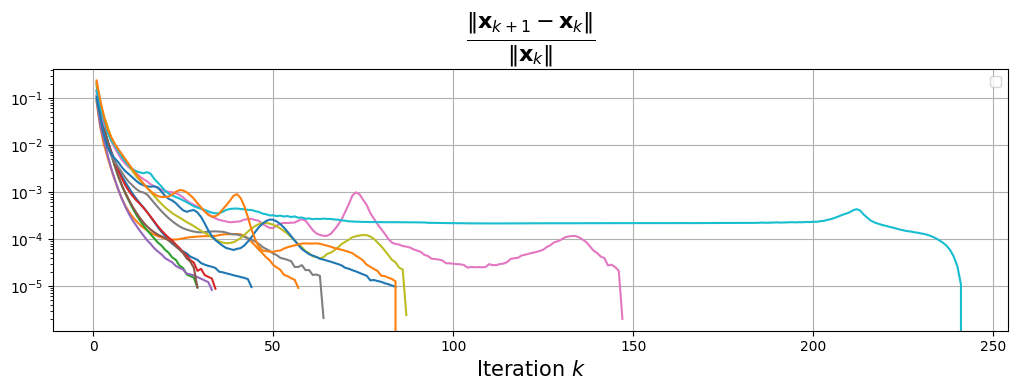

In [4]:
plt.figure(figsize=(20, 4))

for i in range(len(reses)):
    plt.subplot(1, 2, 1)
    res = reses[i]
    plt.grid('on')
    plt.plot(res)
    plt.legend()
    plt.yscale('log')
    plt.title('$\\frac{\|\mathbf{x}_{k+1}-\mathbf{x}_{k}\|}{\|\mathbf{x}_{k}\|}$', fontsize=23)
    plt.xlabel('Iteration $k$', fontsize=15)

plt.legend()
plt.tight_layout()
plt.savefig('fig_data/reses_deblur.pdf', bbox_inches='tight')
plt.show()




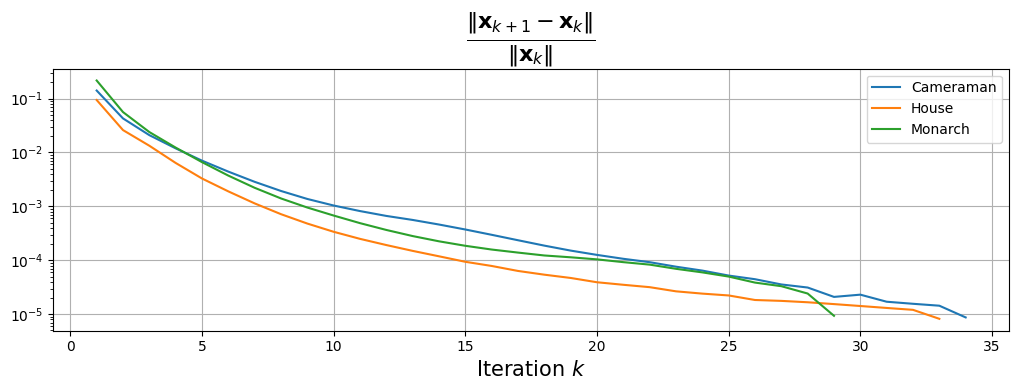

In [ ]:
plt.figure(figsize=(20, 4))
labels = ['Cameraman', 'House', 'Monarch']
for i in [3, 4, 5]:
    plt.subplot(1, 2, 1)
    res = reses[i]
    plt.grid('on')
    plt.plot(res,  label=labels[i-3])
    plt.legend()
    plt.yscale('log')
    plt.title('$\\frac{\|\mathbf{x}_{k+1}-\mathbf{x}_{k}\|}{\|\mathbf{x}_{k}\|}$', fontsize=23)
    plt.xlabel('Iteration $k$', fontsize=15)

plt.legend()
plt.tight_layout()
plt.savefig('fig_data/reses_deblur_figure.pdf', bbox_inches='tight')
plt.show()


